# Tutorial 3: Train NicheTrans on SMA data

In [1]:
import os, time, datetime, warnings

import torch
import torch.nn as nn
from torch.optim import lr_scheduler

from model.nicheTrans_img import *
from datasets.data_manager_SMA import SMA

from utils.utils import *
from utils.notebook_hparams import build_model_from_args
from utils.utils_training_SMA import train, test
from utils.utils_dataloader import *

warnings.filterwarnings("ignore")

### Initialize the args and fix seeds

In [2]:
%run ./args/args_SMA.py
args = args

set_seed(args.seed)
if torch.cuda.is_available():
    os.environ['CUDA_VISIBLE_DEVICES'] = args.gpu_devices

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device: {}".format(device))
print("==========\nArgs:{}\n==========".format(args))

Using device: cpu
Args:Namespace(noise_rate=0.2, dropout_rate=0.1, use_moe_ffn=True, num_experts=8, moe_gate_hidden_dim=512, moe_gate_type='softmax', ffn_mult=2, moe_router_temperature_enable=True, moe_router_temperature_start=1.0, moe_router_temperature_mid=0.7, moe_router_temperature_end=0.5, moe_router_temperature_schedule='step', moe_balance_loss_enable=False, moe_balance_loss_weight=0.001, moe_balance_loss_type='mse_uniform', moe_router_entropy_penalty_enable=True, moe_router_entropy_penalty_weight=0.001, n_source=3000, n_target=50, img_size=256, workers=4, path_img='/mnt/datadisk0/Processed_DATA/2023_nbt_SMA/Processed_data_used/patches', rna_path='/mnt/datadisk0/Processed_DATA/2023_nbt_SMA/Processed_data_used', msi_path='/mnt/datadisk0/Processed_DATA/2023_nbt_SMA/Processed_data_used', max_epoch=40, stepsize=20, train_batch=32, test_batch=32, optimizer='adam', lr=0.0003, gamma=0.1, weight_decay=0.0005, seed=1, save_dir='./log', eval_step=1, gpu_devices='0')


### Initialize dataloaders and NicheTrans

In [ ]:
# create the dataloaders
dataset = SMA(path_img=args.path_img, rna_path=args.rna_path, msi_path=args.msi_path, n_top_genes=args.n_source, n_top_targets=args.n_target)
trainloader, testloader = sma_dataloader(args, dataset)

# create the model
source_dimension, target_dimension = dataset.rna_length, dataset.msi_length
model = build_model_from_args(NicheTrans, args, source_length=source_dimension, target_length=target_dimension)
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

------Calculating spatial graph...
The graph contains 12134 edges, 3120 cells.
3.8891 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 24190 edges, 3120 cells.
7.7532 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 11322 edges, 2918 cells.
3.8801 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 22578 edges, 2918 cells.
7.7375 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 10360 edges, 2675 cells.
3.8729 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 20628 edges, 2675 cells.
7.7114 neighbors per cell on average.
=> SMA loaded
Dataset statistics:
  ------------------------------
  subset   | # num | 
  ------------------------------
  train    |  Without filtering  6038 spots from     2 slides 
  test     |  Without filtering  2675 spots from     1 slides
  train    |  After filting  6005 spots from     2 

### Initialize loss function (criterion) and optimizer

In [4]:
criterion = nn.MSELoss()

if args.optimizer == 'adam':
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
elif args.optimizer == 'SGD':
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr)
else:
    print('unexpected optimizer')

if args.stepsize > 0:
    scheduler = lr_scheduler.StepLR(optimizer, step_size=args.stepsize, gamma=args.gamma)

### Optional MoE Trajectory Tracking During Training

Enable the next cell if you want to monitor whether expert usage becomes more balanced or more specialized across epochs.


In [5]:
from utils.moe_analysis import analyze_moe_routing, summarize_epoch_trajectory

track_moe_during_training = True
moe_track_every = 1
moe_track_max_batches = None  # Set to a small integer for faster monitoring on large datasets.
moe_epoch_frames = {}
moe_epoch_overall = []



### Model training and testing

In [6]:
start_time = time.time()

if "track_moe_during_training" not in globals():
    track_moe_during_training = True
    moe_track_every = 1
    moe_track_max_batches = None
    moe_epoch_frames = {}
    moe_epoch_overall = []

for epoch in range(args.max_epoch):
    last_epoch = epoch + 1 == args.max_epoch

    print("==> Epoch {}/{}".format(epoch+1, args.max_epoch))
    
    ################
    train(model, criterion, optimizer, trainloader, use_img=False, device=device)
    if args.stepsize > 0: scheduler.step()

    if track_moe_during_training and ((epoch + 1) % moe_track_every == 0 or last_epoch):
        moe_epoch_result = analyze_moe_routing(
            model=model,
            dataloader=testloader,
            device=device,
            include_images=False,
            include_cell_information=False,
            include_predictions=False,
            include_targets=False,
            max_batches=moe_track_max_batches,
            add_spatial_regions=False,
        )
        moe_epoch_frames[epoch + 1] = moe_epoch_result["activation_frame"]
        moe_epoch_overall.append({"epoch": epoch + 1, **moe_epoch_result["overall"]})
        print("MoE tracking at epoch {}:".format(epoch + 1), moe_epoch_result["overall"])
    ################

pearson = test(model, testloader, use_img=False, device=device)
torch.save(model.state_dict(), 'NicheTrans_SMA_last.pth')

elapsed = round(time.time() - start_time)
elapsed = str(datetime.timedelta(seconds=elapsed))
print("Finished. Total elapsed time (h:m:s): {}".format(elapsed))


==> Epoch 1/40
Batch 187/187	 Loss 66.389999 (92.108252) | Task 92.108252 | Aux 0.000000 | Tau 1.0000 | Bal 0.000000 | Ent 0.000000 | Margin 0.176101 | Cos 0.483724
MoE tracking at epoch 1: {'num_center_spots': 2655, 'num_experts': 8, 'usage_entropy_normalised': 0.8318100823367548, 'top1_entropy_normalised': 0.4556769442062985, 'effective_expert_count': 5.6389644471989815, 'dominant_expert_fraction': 0.3401938675734628, 'mean_weight_l1_to_uniform': 0.7249588513534778, 'balance_loss': 0.0, 'top1_l1_to_uniform': 1.2875706214689266, 'mean_spot_entropy': 1.1017903477858102, 'std_spot_entropy': 0.06904665042917581, 'mean_gate_margin': 0.2541703782624893, 'std_gate_margin': 0.23206647462655403, 'router_temperature': 1.0, 'router_entropy_penalty': 0.0, 'expert_output_cosine_mean': 0.6263711468648102, 'expert_output_cosine_std': 0.2526258173298701}
==> Epoch 2/40
Batch 187/187	 Loss 27.593840 (42.620788) | Task 42.620788 | Aux 0.000000 | Tau 1.0000 | Bal 0.000000 | Ent 0.000000 | Margin 0.4630

### Optional MoE Routing Analysis

Run the next cell after training if you want to inspect expert activation, load balance, and spatial specialization.


Overall MoE metrics:
{'num_center_spots': 2655, 'num_experts': 8, 'usage_entropy_normalised': 0.5326072656503801, 'top1_entropy_normalised': 0.4056975762727893, 'effective_expert_count': 3.0268596822912865, 'dominant_expert_fraction': 0.7029372479072061, 'mean_weight_l1_to_uniform': 1.1558744841779558, 'balance_loss': 0.0, 'top1_l1_to_uniform': 1.2431261770244821, 'mean_spot_entropy': 0.5649714937447838, 'std_spot_entropy': 0.7441904184268727, 'mean_gate_margin': 0.7230149874318693, 'std_gate_margin': 0.3738391813658476, 'router_temperature': 1.0, 'router_entropy_penalty': 0.0, 'expert_output_cosine_mean': 0.3793090699082714, 'expert_output_cosine_std': 0.3458202325018112}


,expert,average_activation_weight,top1_selection_frequency
0,0,0.034387,0.000000
1,1,0.026855,0.004143
2,2,0.702937,0.693032
3,3,0.001966,0.000000
4,4,0.038399,0.000000
5,5,0.094695,0.178531
6,6,0.077161,0.124294
7,7,0.023598,0.000000


,slice_id,expert_0_mean_weight,expert_1_mean_weight,expert_2_mean_weight,expert_3_mean_weight,expert_4_mean_weight,expert_5_mean_weight,expert_6_mean_weight,expert_7_mean_weight,expert_0_top1_frequency,...,balance_loss,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy,mean_gate_margin,std_gate_margin,router_temperature,router_entropy_penalty,expert_output_cosine_mean,expert_output_cosine_std
0,V11L12-109_A1,0.034387,0.026855,0.702937,0.001966,0.038399,0.094695,0.077161,0.023598,0.0,...,0.0,1.243126,0.564971,0.74419,0.723015,0.373839,1.0,0.0,0.379309,0.34582


,spatial_region,expert_0_mean_weight,expert_1_mean_weight,expert_2_mean_weight,expert_3_mean_weight,expert_4_mean_weight,expert_5_mean_weight,expert_6_mean_weight,expert_7_mean_weight,expert_0_top1_frequency,...,balance_loss,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy,mean_gate_margin,std_gate_margin,router_temperature,router_entropy_penalty,expert_output_cosine_mean,expert_output_cosine_std
0,V11L12-109_A1|x0_y0,7.680167e-02,5.291803e-02,0.513176,1.934937e-03,0.068400,2.045159e-01,7.508814e-02,0.007165,0.0,...,0.0,1.331818,0.895528,0.806447,0.565075,0.405282,1.0,0.0,0.380589,0.345755
1,V11L12-109_A1|x0_y1,1.628935e-02,7.725962e-03,0.744575,1.475167e-03,0.050493,1.041170e-01,4.941957e-02,0.025905,0.0,...,0.0,1.419643,0.533919,0.644078,0.738513,0.334377,1.0,0.0,0.380309,0.344483
2,V11L12-109_A1|x1_y0,3.019024e-08,1.189939e-11,0.999803,2.894526e-07,0.000003,1.301047e-09,9.208228e-08,0.000194,0.0,...,0.0,1.750000,0.001785,0.001921,0.999607,0.000499,1.0,0.0,0.374721,0.348157
3,V11L12-109_A1|x1_y1,1.867522e-02,2.419915e-02,0.720389,3.249994e-03,0.021769,2.821028e-02,1.327033e-01,0.050804,0.0,...,0.0,1.461320,0.536905,0.733446,0.732265,0.369501,1.0,0.0,0.379856,0.345376


,sample_id,slice_id,spot_id,x,y,batch_index,batch_spot_index,top1_expert,top1_weight,center_entropy,...,target_22,target_23,target_24,target_25,target_26,target_27,target_28,target_29,target_30,spatial_region
0,V11L12-109_A1/16_0,V11L12-109_A1,16_0,16.0,0.0,63,24,2,0.998444,0.011709,...,9.459185,9.851337,9.413156,0.0,0.000000,11.124052,10.766718,12.130200,10.306040,V11L12-109_A1|x0_y0
1,V11L12-109_A1/18_0,V11L12-109_A1,18_0,18.0,0.0,48,15,2,0.999405,0.005024,...,0.000000,8.492299,0.000000,0.0,0.000000,8.759887,0.000000,11.104244,10.788660,V11L12-109_A1|x0_y0
2,V11L12-109_A1/20_0,V11L12-109_A1,20_0,20.0,0.0,76,6,2,0.999009,0.007868,...,0.000000,10.286452,0.000000,0.0,8.627494,0.000000,0.000000,11.605639,11.130058,V11L12-109_A1|x0_y0
3,V11L12-109_A1/22_0,V11L12-109_A1,22_0,22.0,0.0,60,1,2,0.998994,0.007975,...,0.000000,11.559565,9.218695,0.0,0.000000,0.000000,0.000000,11.876929,11.200499,V11L12-109_A1|x0_y0
4,V11L12-109_A1/24_0,V11L12-109_A1,24_0,24.0,0.0,32,0,2,0.998335,0.012401,...,0.000000,11.640724,0.000000,0.0,0.000000,8.050138,8.727013,11.898485,7.776558,V11L12-109_A1|x0_y0


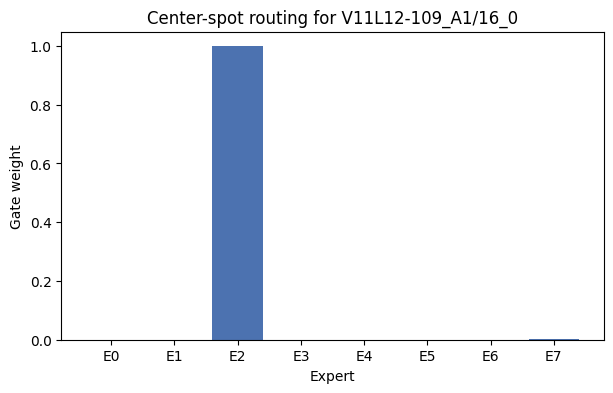

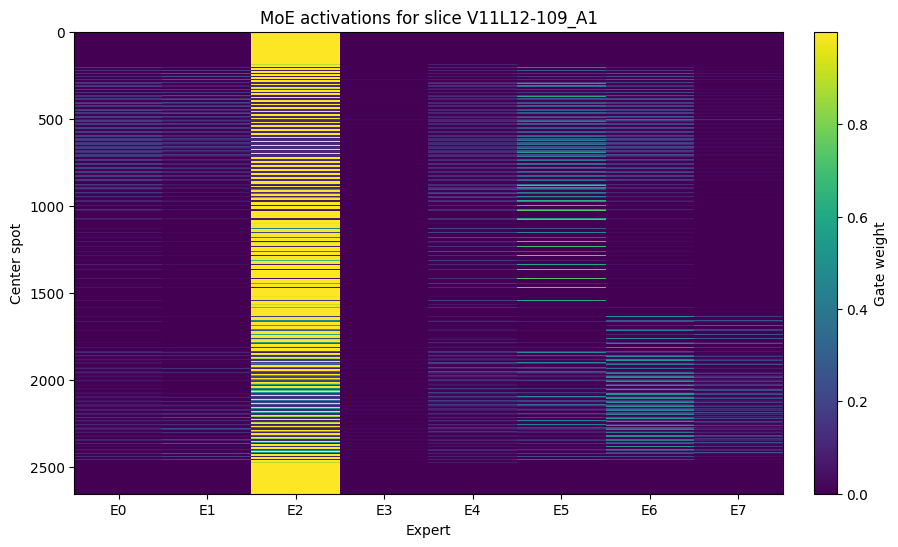

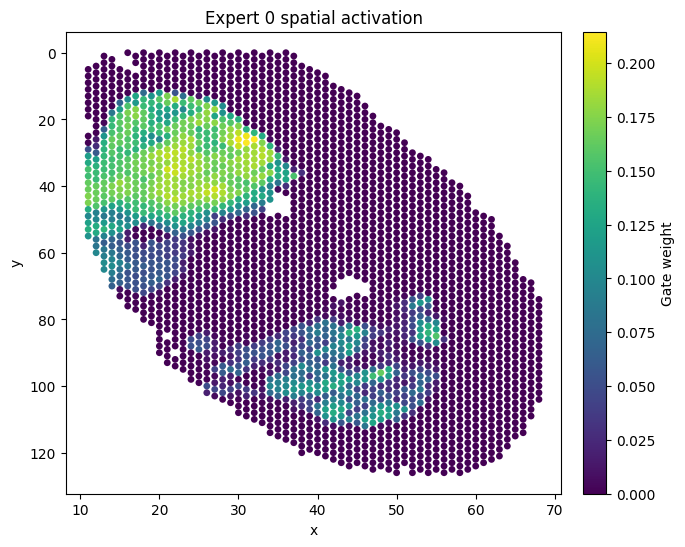

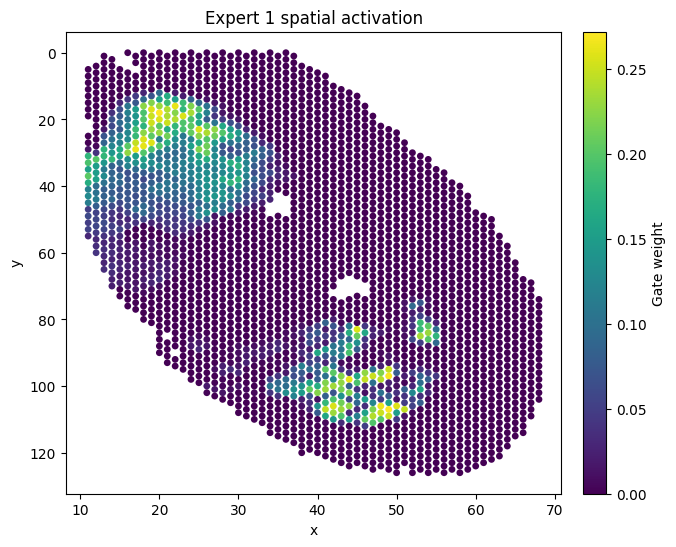

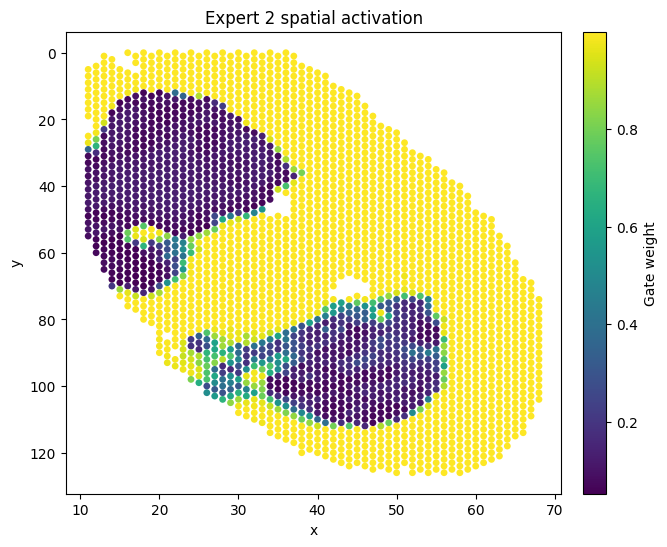

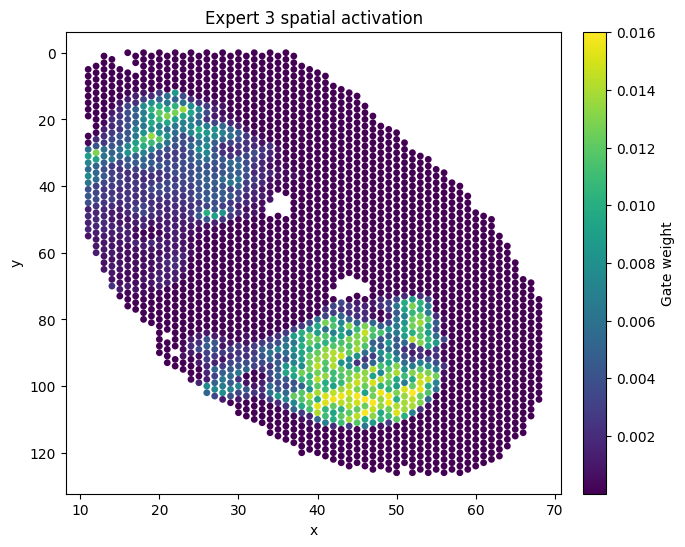

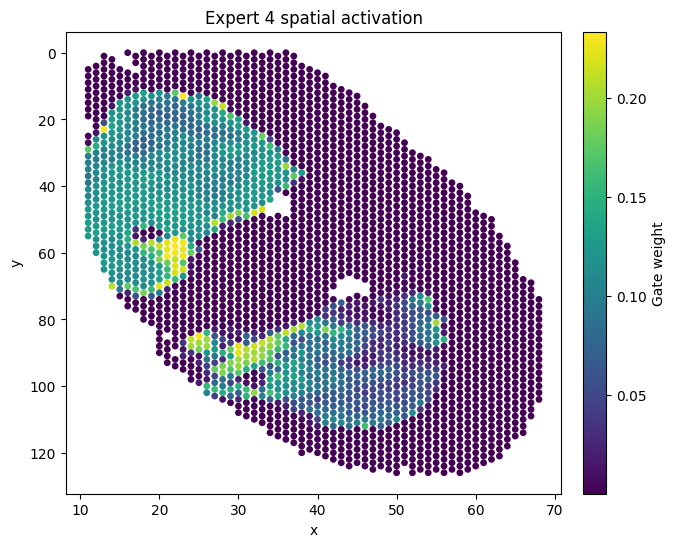

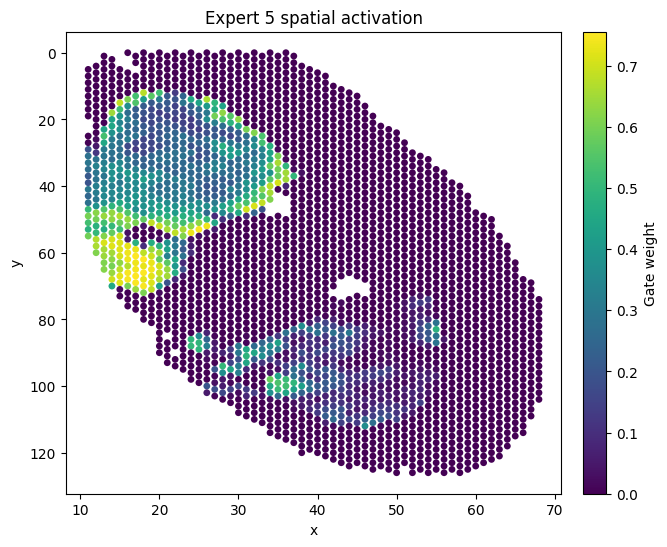

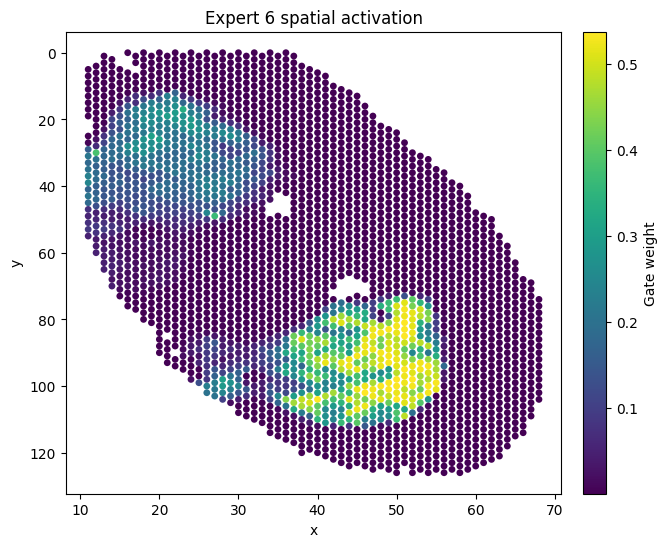

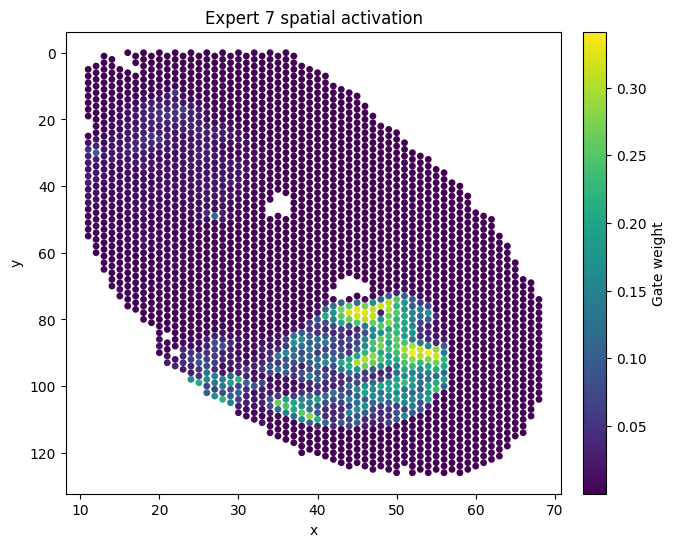

In [9]:
from utils.moe_analysis import (
    analyze_moe_routing,
    plot_center_spot_activation_bar,
    plot_expert_spatial_heatmap,
    plot_slice_activation_heatmap,
    save_moe_analysis_tables,
)

moe_results = analyze_moe_routing(
    model=model,
    dataloader=testloader,
    device=device,
    include_images=False,
    include_cell_information=False,
    include_predictions=False,
    include_targets=True,
)

activation_frame = moe_results["activation_frame"]

print("Overall MoE metrics:")
print(moe_results["overall"])
display(moe_results["expert_summary"])
if not moe_results["slice_summary"].empty:
    display(moe_results["slice_summary"])
if not moe_results["region_summary"].empty:
    display(moe_results["region_summary"])

display(activation_frame.head())
plot_center_spot_activation_bar(activation_frame, row_index=0);

if activation_frame["x"].notna().any() and activation_frame["y"].notna().any():
    first_slice = activation_frame["slice_id"].dropna().iloc[0]
    plot_slice_activation_heatmap(activation_frame, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=0, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=1, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=2, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=3, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=4, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=5, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=6, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=7, slice_id=first_slice);

else:
    print(
        "Spatial coordinates were not recovered from the sample ids. "
        "Pass `sample_metadata_resolver` to `analyze_moe_routing(...)` if you want spatial heatmaps."
    )

# Optional: save the analysis tables to disk.
# save_moe_analysis_tables(moe_results, output_dir="./moe_analysis")



### Optional MoE Training Trajectory Summary

If epoch-level tracking was enabled during training, the next cell summarizes how expert usage changed over time.


,epoch,num_center_spots,num_experts,usage_entropy_normalised,top1_entropy_normalised,effective_expert_count,dominant_expert_fraction,mean_weight_l1_to_uniform,balance_loss,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy,mean_gate_margin,std_gate_margin,router_temperature,router_entropy_penalty,expert_output_cosine_mean,expert_output_cosine_std
0,1,2655,8,0.831810,0.455677,5.638964,0.340194,0.724959,0.0,1.287571,1.101790,0.069047,0.254170,0.232066,1.0,0.0,0.626371,0.252626
1,2,2655,8,0.565129,0.350001,3.238638,0.458340,1.162036,0.0,1.485687,0.484772,0.444605,0.595296,0.370768,1.0,0.0,0.327161,0.468523
2,3,2655,8,0.727395,0.424508,4.538404,0.559992,0.869984,0.0,1.366667,0.974719,0.952235,0.530580,0.459715,1.0,0.0,0.546875,0.277091
3,4,2655,8,0.723369,0.594553,4.500570,0.548497,0.846994,0.0,1.015725,1.009623,0.913404,0.495284,0.468057,1.0,0.0,0.485141,0.312219
4,5,2655,8,0.682960,0.390818,4.137847,0.593319,0.936637,0.0,1.393032,0.949273,0.893020,0.535833,0.448760,1.0,0.0,0.420449,0.386460
5,6,2655,8,0.618581,0.273805,3.619379,0.645178,1.040357,0.0,1.500000,0.848230,0.879830,0.599975,0.428454,1.0,0.0,0.373520,0.445427
6,7,2655,8,0.626099,0.346363,3.676405,0.646118,1.042236,0.0,1.328908,0.891709,0.877196,0.567271,0.440261,1.0,0.0,0.361562,0.476186
7,8,2655,8,0.634024,0.458932,3.737499,0.630170,1.010340,0.0,1.205461,0.864258,0.838896,0.565671,0.437798,1.0,0.0,0.346243,0.473247
8,9,2655,8,0.573220,0.321745,3.293590,0.682704,1.115408,0.0,1.408098,0.784600,0.861106,0.602494,0.447621,1.0,0.0,0.393241,0.455458
9,10,2655,8,0.572089,0.427936,3.285850,0.684373,1.118746,0.0,1.229473,0.748960,0.858950,0.615960,0.450614,1.0,0.0,0.380895,0.458080


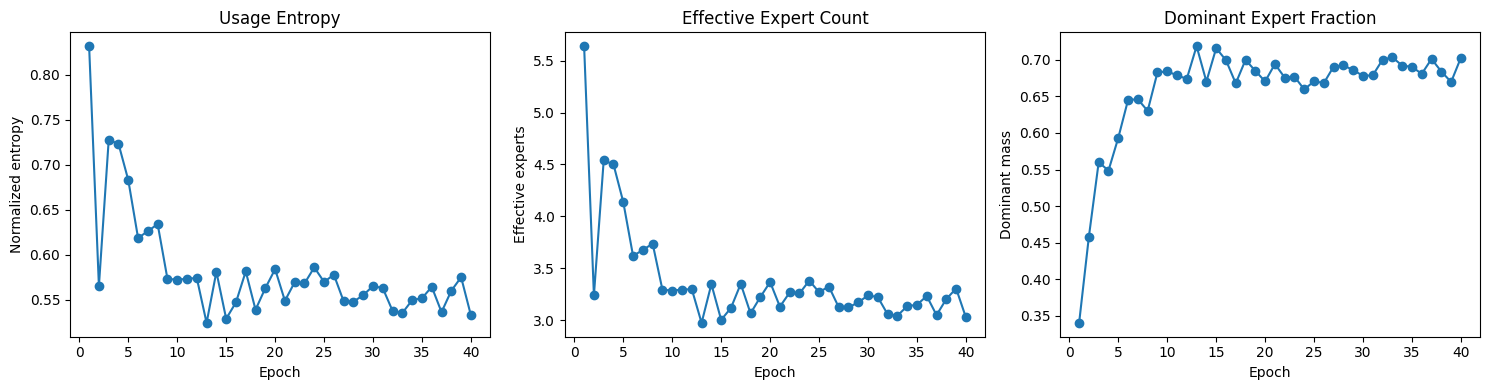

In [10]:
import matplotlib.pyplot as plt

if not moe_epoch_frames:
    print(
        "No epoch-level MoE trajectory was recorded. "
        "Set `track_moe_during_training = True` before training and rerun the notebook if you want this summary."
    )
else:
    moe_epoch_trajectory = summarize_epoch_trajectory(moe_epoch_frames)
    display(moe_epoch_trajectory)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["usage_entropy_normalised"], marker="o")
    axes[0].set_title("Usage Entropy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Normalized entropy")

    axes[1].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["effective_expert_count"], marker="o")
    axes[1].set_title("Effective Expert Count")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Effective experts")

    axes[2].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["dominant_expert_fraction"], marker="o")
    axes[2].set_title("Dominant Expert Fraction")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Dominant mass")

    plt.tight_layout()

# Optional: save the trajectory table to disk.
# moe_epoch_trajectory.to_csv("./moe_analysis/moe_epoch_trajectory.csv", index=False)

